In [1]:
import getpass
import os
import json
from typing import List, Literal
from pprint import pprint

from pydantic import BaseModel, Field
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_community.tools.tavily_search import TavilySearchResults
from typing_extensions import TypedDict

from kagraph import END, StateGraph, START
from kagraph.llms import load_llm
from kagraph.messages import HumanMessage, SystemMessage
from kagraph import prompt_llm

from kagraph.tracing import trace

C:\Users\anpro\AppData\Local\Temp\ipykernel_7176\3560124841.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("TAVILY_API_KEY")

In [3]:
# Using KaGraph's native LLM loader instead of LangChain's ChatOpenAI
llm = load_llm("qwen/qwen3-next-80b-a3b-instruct", support_structured_outputs=True)

In [4]:
# ==============================================================================
# Helpers
# ==============================================================================

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [5]:
# ==============================================================================
# Build Index
# ==============================================================================
embd = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=0
)
doc_splits = text_splitter.split_documents(docs_list)

vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=embd,
)
retriever = vectorstore.as_retriever()

C:\Users\anpro\AppData\Local\Temp\ipykernel_7176\1503469977.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embd = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

e:\miniconda3\envs\kagent\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\anpro\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
web_search_tool = TavilySearchResults(k=3)

C:\Users\anpro\AppData\Local\Temp\ipykernel_7176\3405644020.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k=3)


In [7]:
# ==============================================================================
# Pydantic Schemas for Structured Outputs
# ==============================================================================
class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""
    datasource: Literal["vectorstore", "web_search"] = Field(
        ...,
        description="Given a user question choose to route it to web search or a vectorstore.",
    )

class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""
    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )

class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""
    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )

In [8]:
# ==============================================================================
# Graph State and Nodes
# ==============================================================================
class GraphInput(TypedDict):
    question: str

class GraphState(TypedDict, total=False):
    """
    Represents the state of our graph.
    """
    question: str
    generation: str
    documents: List[Document]

def retrieve(state):
    print("---RETRIEVE---")
    question = state["question"]
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

def generate(state):
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]
    docs_txt = format_docs(documents)
    
    sys_msg = SystemMessage(
        "You are an assistant for question-answering tasks. Use the following pieces of "
        "retrieved context to answer the question. If you don't know the answer, just say "
        "that you don't know. Use three sentences maximum and keep the answer concise.\n\n"
        f"Context: {docs_txt}"
    )
    hum_msg = HumanMessage(question)
    
    generation = prompt_llm(llm, prompt=None, messages=[hum_msg], system=sys_msg.content)
    return {"documents": documents, "question": question, "generation": generation}

def grade_documents(state):
    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]
    filtered_docs = []
    
    sys_msg = SystemMessage(
        "You are a grader assessing relevance of a retrieved document to a user question. \n"
        "If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n"
        "It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n"
        "Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."
    )
    
    for d in documents:
        hum_msg = HumanMessage(f"Retrieved document: \n\n {d.page_content} \n\n User question: {question}")
        response = llm.invoke([hum_msg], system=sys_msg.content, response_format=GradeDocuments)
        try:
            score = GradeDocuments.model_validate_json(response.content)
            grade = score.binary_score.lower()
        except Exception:
            grade = "no"
            
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            
    return {"documents": filtered_docs, "question": question}

def transform_query(state):
    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state.get("documents", [])
    
    sys_msg = SystemMessage(
        "You a question re-writer that converts an input question to a better version that is optimized "
        "for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."
    )
    hum_msg = HumanMessage(f"Here is the initial question: \n\n {question} \n Formulate an improved question.")
    
    better_question = prompt_llm(llm, prompt=None, messages=[hum_msg], system=sys_msg.content)
    return {"documents": documents, "question": better_question}

def web_search(state):
    print("---WEB SEARCH---")
    question = state["question"]
    docs = web_search_tool.invoke({"query": question})
    web_results = "\n".join([d["content"] for d in docs])
    web_results = Document(page_content=web_results)
    return {"documents": [web_results], "question": question}

def route_question(state):
    print("---ROUTE QUESTION---")
    question = state["question"]
    
    sys_msg = SystemMessage(
        "You are an expert at routing a user question to a vectorstore or web search.\n"
        "The vectorstore contains documents related to agents, prompt engineering, and adversarial attacks.\n"
        "Use the vectorstore for questions on these topics. Otherwise, use web-search."
    )
    hum_msg = HumanMessage(question)
    
    try:
        data = prompt_llm(llm, prompt=None, messages=[hum_msg], system=sys_msg.content, schema=RouteQuery)
        if isinstance(data, RouteQuery):
            source = data.datasource
        elif isinstance(data, dict):
            source = data.get("datasource", "web_search")
        else:
            source = RouteQuery.model_validate_json(data).datasource
    except Exception:
        source = "web_search"
        
    if source == "web_search":
        print("---ROUTE QUESTION TO WEB SEARCH---")
        return "web_search"
    else:
        print("---ROUTE QUESTION TO RAG---")
        return "vectorstore"

def decide_to_generate(state):
    print("---ASSESS GRADED DOCUMENTS---")
    filtered_documents = state.get("documents", [])
    if not filtered_documents:
        print("---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---")
        return "transform_query"
    else:
        print("---DECISION: GENERATE---")
        return "generate"

def grade_generation_v_documents_and_question(state):
    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]
    docs_txt = format_docs(documents)

    hallucination_sys = SystemMessage(
        "You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n"
        "Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."
    )
    hallucination_hum = HumanMessage(f"Set of facts: \n\n {docs_txt} \n\n LLM generation: {generation}")
    
    try:
        score = prompt_llm(llm, prompt=None, messages=[hallucination_hum], system=hallucination_sys.content, schema=GradeHallucinations)
        if isinstance(score, GradeHallucinations):
            grade = score.binary_score.lower()
        elif isinstance(score, dict):
            grade = score.get("binary_score", "no").lower()
        else:
            grade = GradeHallucinations.model_validate_json(score).binary_score.lower()
    except Exception:
        grade = "no"
        
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        print("---GRADE GENERATION vs QUESTION---")
        
        answer_sys = SystemMessage(
            "You are a grader assessing whether an answer addresses / resolves a question \n"
            "Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."
        )
        answer_hum = HumanMessage(f"User question: \n\n {question} \n\n LLM generation: {generation}")
        
        try:
            ans_score = prompt_llm(llm, prompt=None, messages=[answer_hum], system=answer_sys.content, schema=GradeAnswer)
            if isinstance(ans_score, GradeAnswer):
                ans_grade = ans_score.binary_score.lower()
            elif isinstance(ans_score, dict):
                ans_grade = ans_score.get("binary_score", "no").lower()
            else:
                ans_grade = GradeAnswer.model_validate_json(ans_score).binary_score.lower()
        except Exception:
            ans_grade = "no"
            
        if ans_grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
    else:
        print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"

In [9]:
# ==============================================================================
# Compile Graph
# ==============================================================================
workflow = StateGraph(GraphState, input_schema=GraphInput)

workflow.add_node("web_search", web_search)
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("transform_query", transform_query)

workflow.add_conditional_edges(
    START,
    route_question,
    {
        "web_search": "web_search",
        "vectorstore": "retrieve",
    },
)

workflow.add_edge("web_search", "generate")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "retrieve")
workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "generate",
        "useful": END,
        "not useful": "transform_query",
    },
)

app = workflow.compile()

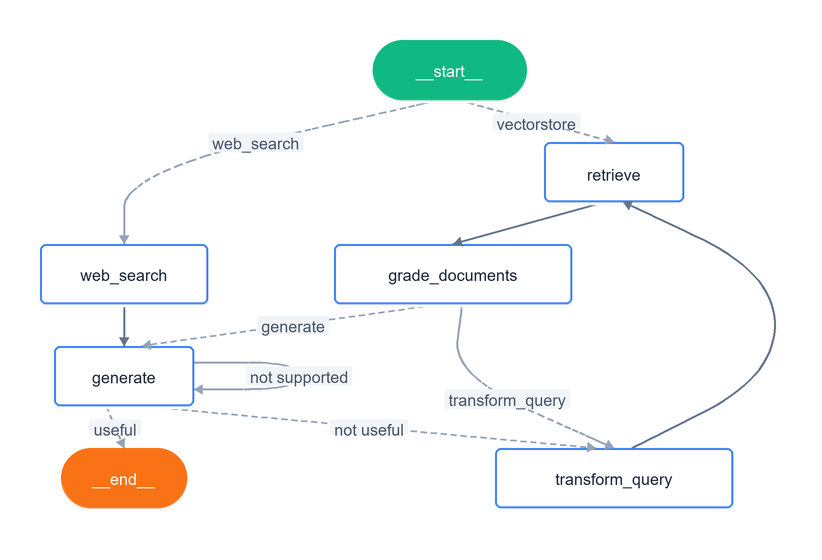

In [10]:
app.get_graph().draw_png()

In [11]:
inputs = {
    "question": "Cho tôi 1 ít thông tin về Prompt Engineering?"
}
with trace("AdaptiveRAG"):
    result = app.invoke(inputs, chat_name="AdaptiveRAG-Chat")
    pprint(result.get("generation"))

---ROUTE QUESTION---
---ROUTE QUESTION TO RAG---
---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---
('Prompt Engineering là kỹ thuật điều chỉnh cách người dùng giao tiếp với mô '
 'hình ngôn ngữ lớn (LLM) để định hướng hành vi của mô hình mà không cần cập '
 'nhật trọng số. Nó bao gồm các phương pháp như zero-shot, few-shot và '
 'Chain-of-Thought để cải thiện độ chính xác và sự phù hợp của câu trả lời. '
 'Đây là một lĩnh vực thực nghiệm, đòi hỏi thử nghiệm nhiều phương pháp do '
 'hiệu quả thay đổi tùy theo mô hình.')
